In [1]:
from trading_engine.core import run_full_backtest
import datetime
import matplotlib.pyplot as plt
import polars as pl

In [2]:
# 1) experiment config
universe = [
  'TLT-US', 'IEI-US', 'SHY-US', 'BIL-US', 'SLV-US', 'GLD-US',
  'USO-US', 'UNG-US', 'SPY-US', 'EWJ-US', 'INDA-US', 'MCHI-US',
  'IBIT-US', 'ETHA-US', 'EZU-US', 'VIXY-US'
]
features = ["close_momentum_10", "close_momentum_20", "close_momentum_30", "close_momentum_60", "close_momentum_90", "close_momentum_120", "close_momentum_240"]

# AMMA models defined in src/trading_engine/models/registry.py
models = [
    "TLT_AMMA",
    "IEI_AMMA",
    "SHY_AMMA",
    "BIL_AMMA",
    "SLV_AMMA",
    "GLD_AMMA",
    "SPY_AMMA",
    "INDA_AMMA",
    "MCHI_AMMA",
    "IBIT_AMMA",
    "ETHA_AMMA",
    "EZU_AMMA",
]

aggregators   = ["model_mvo_amma_constrained"]
optimizers    = ["mean_variance_constrained"]
initial_value = 1000000
start_date = datetime.date(2024, 1, 1)
end_date = datetime.date(2026, 12, 31)

In [3]:
results = run_full_backtest(
    universe=universe,
    features=features,
    models=models,
    aggregators=aggregators,
    optimizers=optimizers,
    start_date=start_date,
    end_date=end_date,
    initial_value=initial_value,
)

In [4]:
results["optimizer_simulations"]["mean_variance_constrained"]["backtest_metrics"]


metric,value
str,f64
"""total_return""",0.340773
"""annualized_return""",0.171051
"""annualized_volatility""",0.076581
"""sharpe_ratio""",2.233586
"""sortino_ratio""",2.181709
…,…
"""num_weight_events""",468.0
"""parsing_time_ms""",5.0
"""simulation_time_ms""",11.0


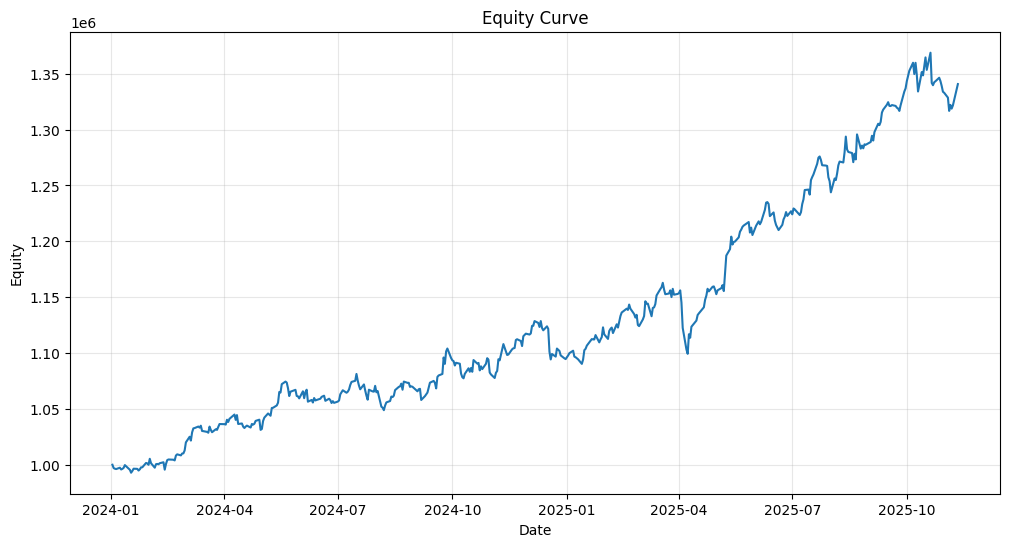

In [5]:
df = results["optimizer_simulations"]["mean_variance_constrained"]["backtest_results"]


df = df.with_columns(
        pl.col("date").str.to_date()
    )
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['portfolio_value'])
plt.title('Equity Curve')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.grid(True, alpha=0.3)
plt.show()



In [60]:
results["optimizer_simulations"]["mean_variance_constrained"]["backtest_weights"][-1]


date,UNG-US,MCHI-US,USO-US,SLV-US,GLD-US,INDA-US,IBIT-US,EWJ-US,SPY-US,SHY-US,VIXY-US,ETHA-US,IEI-US,TLT-US,BIL-US,EZU-US,cash
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2025-10-29""",-0.000005,0.057943,-0.000004,0.039948,0.073651,0.11375,0.036585,-0.000013,0.103544,0.119766,0.000048,0.013815,0.111604,0.118399,0.11062,0.10032,0.000029
